In [ ]:
!pip install pandas scikit-learn nltk

In [ ]:
!pip install torch

In [ ]:
#!pip uninstall torch torchvision torchaudio -y

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_recall_fscore_support

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, get_scheduler
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm.auto import tqdm

from sklearn.metrics import confusion_matrix

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
df = pd.read_csv('/content/VKR_dataset-F.csv')
df.head()

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Hi! You just spoke to DEEPAK. We'd like to kno...,No,No,No
1,ham,Yay can't wait to party together!,No,No,No
2,ham,At what time are you coming.,No,No,No
3,smishing,"Dear customer your PAY2TMKYC has been expired,...",No,No,Yes
4,ham,Yo you around? A friend of mine's lookin to pi...,No,No,No


In [4]:
df.shape

(21734, 5)

In [5]:
df = df[['LABEL', 'TEXT']]

In [6]:
df = df.dropna()

In [7]:
df.shape

(16162, 2)

In [8]:
df['LABEL'] = df['LABEL'].str.lower()

In [9]:
df['LABEL'].value_counts()

,count
LABEL,
ham,8241
smishing,4035
spam,3886


In [10]:
stop_words = set(stopwords.words('english'))

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return ' '.join(words)

df['clean_text'] = df['TEXT'].apply(clean_text)

In [12]:
df

,LABEL,TEXT,clean_text
0,ham,Hi! You just spoke to DEEPAK. We'd like to kno...,hi spoke deepak wed like know satisfied experi...
1,ham,Yay can't wait to party together!,yay cant wait party together
2,ham,At what time are you coming.,time coming
3,smishing,"Dear customer your PAY2TMKYC has been expired,...",dear customer paytmkyc expired blcked within h...
4,ham,Yo you around? A friend of mine's lookin to pi...,yo around friend mines lookin pick later tonight
...,...,...,...
16157,ham,:( but your not here....,
16158,ham,Becoz its &lt;#&gt; jan whn al the post ofic...,becoz ltgt jan whn al post ofice holiday cn go...
16159,ham,Its a valentine game. . . send dis msg to all ...,valentine game send dis msg ur friends answers...
16160,ham,We r outside already.,r outside already


In [13]:
le = LabelEncoder()
df['LABEL_ENC'] = le.fit_transform(df['LABEL'])

In [14]:
df['LABEL_ENC'].value_counts()

,count
LABEL_ENC,
0,8241
1,4035
2,3886


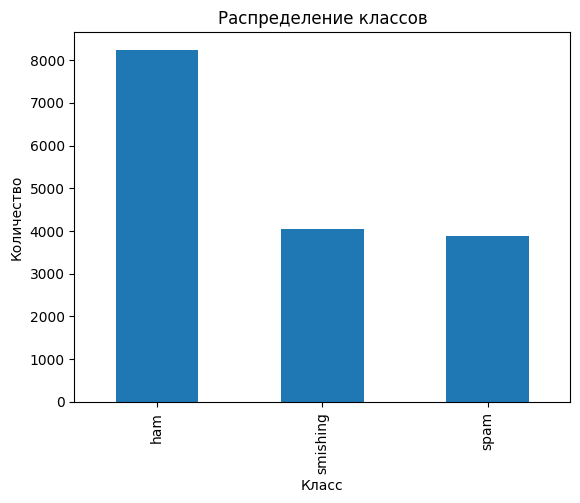

In [ ]:
plt.figure()
df['LABEL'].value_counts().plot(kind='bar')
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.show()

In [ ]:
class_counts = df['LABEL'].value_counts()
class_percent = df['LABEL'].value_counts(normalize=True) * 100
print("\nПроцентное соотношение классов:\n", class_percent)


Процентное соотношение классов:
 LABEL
ham         50.989976
smishing    24.965970
spam        24.044054
Name: proportion, dtype: float64


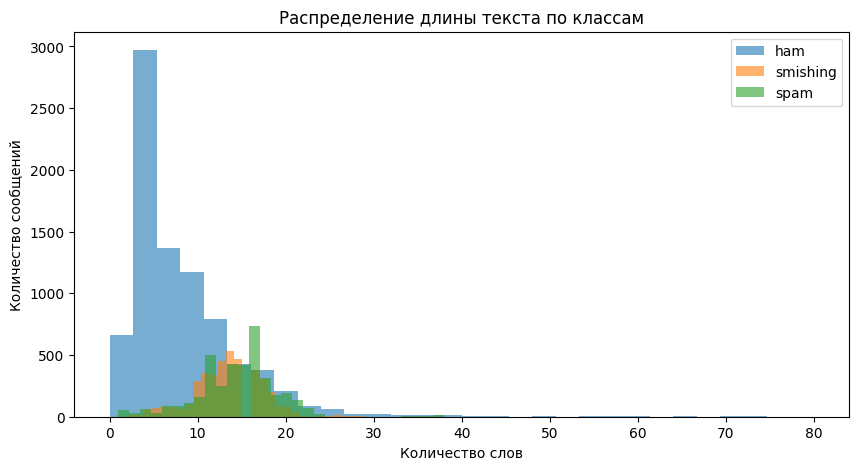

In [ ]:
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
for label in df['LABEL'].unique():
    subset = df[df['LABEL'] == label]
    plt.hist(subset['text_length'], bins=30, alpha=0.6, label=label)

plt.title("Распределение длины текста по классам")
plt.xlabel("Количество слов")
plt.ylabel("Количество сообщений")
plt.legend()
plt.show()

In [ ]:
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

In [ ]:
mean_length_all = df['text_length'].mean()
median_length_all = df['text_length'].median()
max_length_all = df['text_length'].max()
min_length_all = df['text_length'].min()

print(f"Средняя длина текста: {mean_length_all:.2f} слов")
print(f"Медианная длина текста: {median_length_all} слов")
print(f"Минимальная длина текста: {min_length_all} слов")
print(f"Максимальная длина текста: {max_length_all} слов")

print("\nСредняя длина текста по классам:")
print(df.groupby('LABEL')['text_length'].mean())

Средняя длина текста: 10.95 слов
Медианная длина текста: 11.0 слов
Минимальная длина текста: 0 слов
Максимальная длина текста: 80 слов

Средняя длина текста по классам:
LABEL
ham          8.022570
smishing    13.448823
spam        14.543489
Name: text_length, dtype: float64


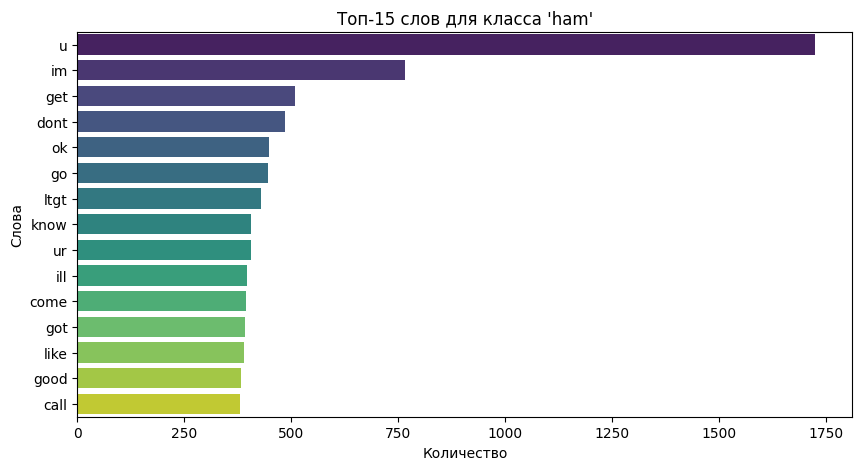

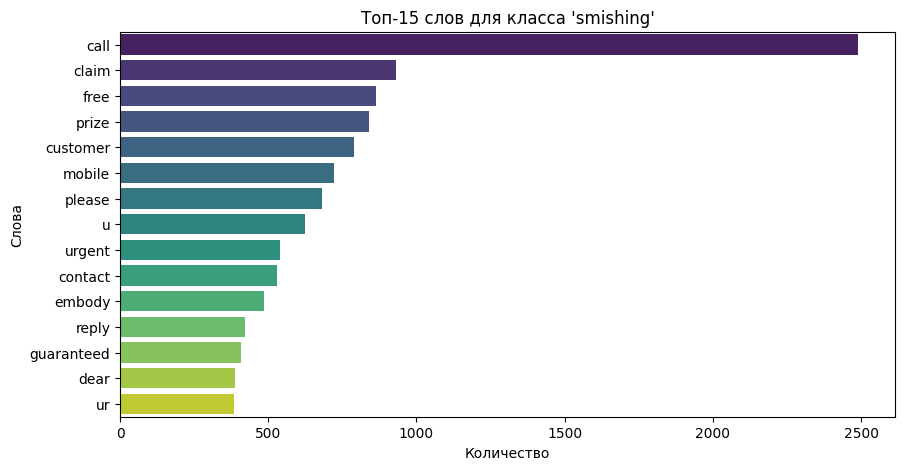

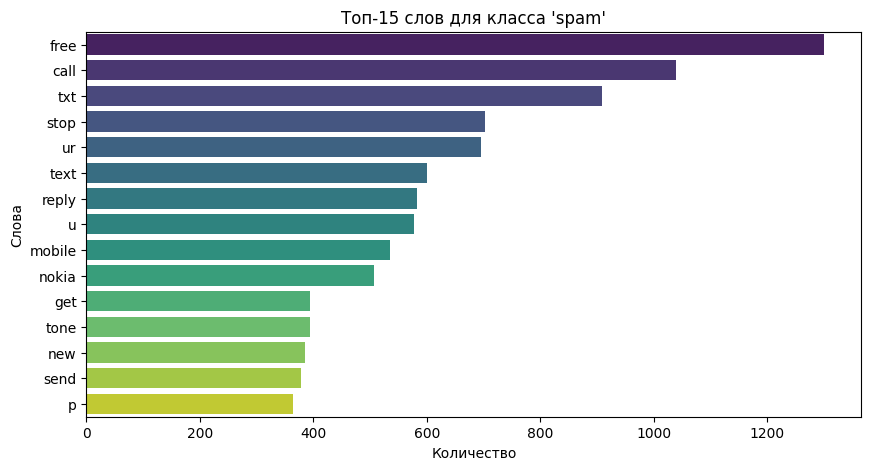

In [15]:
from collections import Counter
import seaborn as sns

top_n = 15

for label in df['LABEL'].unique():
    words = ' '.join(df[df['LABEL'] == label]['clean_text']).split()
    word_counts = Counter(words)
    common_words = word_counts.most_common(top_n)

    words, counts = zip(*common_words)

    plt.figure(figsize=(10,5))
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.title(f"Топ-{top_n} слов для класса '{label}'")
    plt.xlabel("Количество")
    plt.ylabel("Слова")
    plt.show()

In [ ]:
train_idx, test_idx = train_test_split(df.index,test_size=0.2,random_state=42,stratify=df['LABEL_ENC'])
train_df = df.loc[train_idx].reset_index(drop=True)
test_df = df.loc[test_idx].reset_index(drop=True)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

In [ ]:
y_train = train_df['LABEL_ENC']
y_test = test_df['LABEL_ENC']

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_lr)

0.9780389730900093

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1649
           1       0.96      0.97      0.97       807
           2       0.95      0.96      0.96       777

    accuracy                           0.98      3233
   macro avg       0.97      0.97      0.97      3233
weighted avg       0.98      0.98      0.98      3233



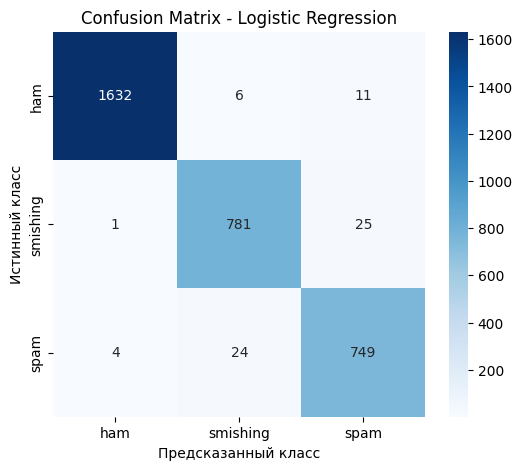

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)
labels = le.classes_

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

В датасете наблюдается умеренный дисбаланс классов (примерно 2:1:1).
Однако результаты экспериментов показывают, что модель демонстрирует
высокие значения precision, recall и F1-score для всех классов.

Макро- и взвешенные метрики практически совпадают, что свидетельствует
об отсутствии существенного влияния дисбаланса на качество модели.
В связи с этим дополнительные методы балансировки классов не применялись.

In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_nb)

0.9539127745128364

In [ ]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1649
           1       0.93      0.93      0.93       807
           2       0.93      0.90      0.92       777

    accuracy                           0.95      3233
   macro avg       0.95      0.94      0.94      3233
weighted avg       0.95      0.95      0.95      3233



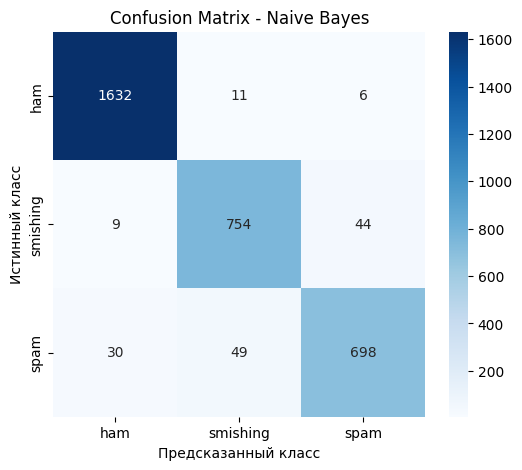

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb)
labels = le.classes_

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [ ]:
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

In [ ]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:32:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=3, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [200, 300], 'subsample': [0.8, 1.0]},
             scoring='f1_weighted', verbose=1)

In [ ]:
grid.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 8,
 'n_estimators': 300,
 'subsample': 1.0}

In [ ]:
xgb_model = grid.best_estimator_
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_xgb)

0.9789669038045159

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1649
           1       0.97      0.96      0.97       807
           2       0.96      0.96      0.96       777

    accuracy                           0.98      3233
   macro avg       0.97      0.97      0.97      3233
weighted avg       0.98      0.98      0.98      3233



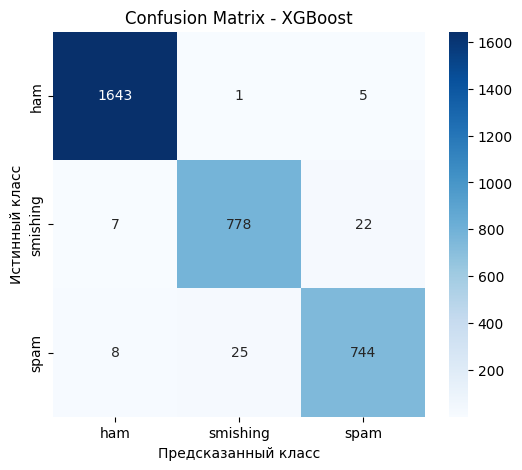

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)
labels = le.classes_

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [ ]:
!pip install transformers datasets --quiet

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
X_train_texts = train_df['TEXT']
X_test_texts = test_df['TEXT']

y_train_labels = train_df['LABEL_ENC']
y_test_labels = test_df['LABEL_ENC']

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

In [ ]:
train_encodings = tokenizer(
    list(X_train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
class SMSDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

In [ ]:
train_dataset = SMSDataset(train_encodings, y_train_labels)
test_dataset = SMSDataset(test_encodings, y_test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased',num_labels=len(df['LABEL_ENC'].unique()))
model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
optimizer = AdamW(model.parameters(), lr=5e-5)

In [ ]:
import time

In [ ]:
num_epochs = 3
num_training_steps = num_epochs * len(train_loader)

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

#progress_bar = tqdm(range(num_training_steps))
start_time_distil = time.time()
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    preds = []
    true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            preds.extend(predictions.cpu().numpy())
            true_labels.extend(batch['labels'].cpu().numpy())

    acc = accuracy_score(true_labels, preds)
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Val Accuracy = {acc:.4f}")
end_time_distil = time.time()
total_time = end_time_distil - start_time_distil

Epoch 1: Loss = 0.1505, Val Accuracy = 0.9799
Epoch 2: Loss = 0.0473, Val Accuracy = 0.9833
Epoch 3: Loss = 0.0296, Val Accuracy = 0.9861


In [ ]:
total_time

459.5104959011078

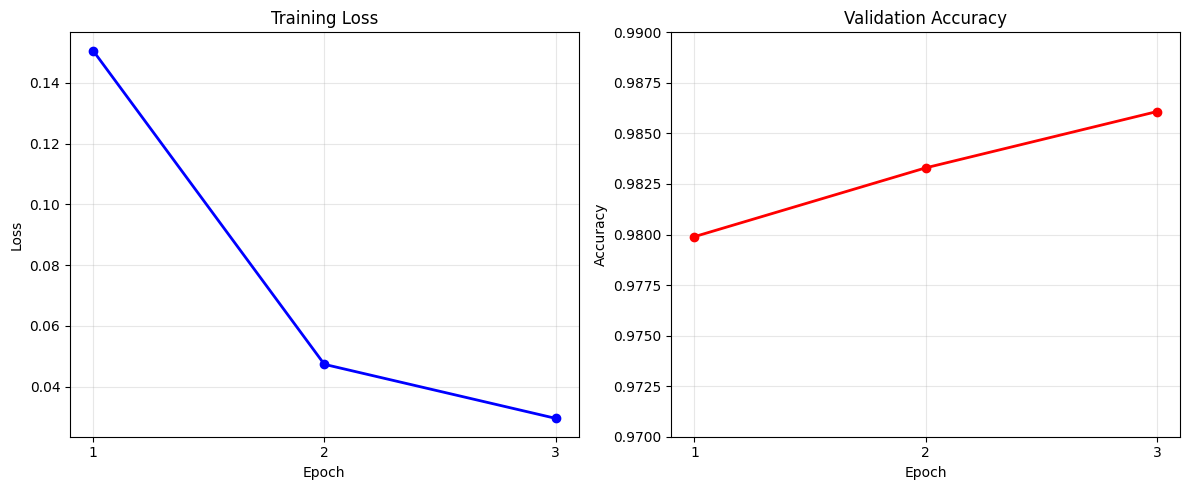

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.plot(range(1, len(train_losses)+1), train_losses, marker='o', color='blue', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, len(train_losses)+1))

ax2.plot(range(1, len(val_accuracies)+1), val_accuracies, marker='o', color='red', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, len(val_accuracies)+1))
ax2.set_ylim(0.97, 0.99)

plt.tight_layout()
plt.show()

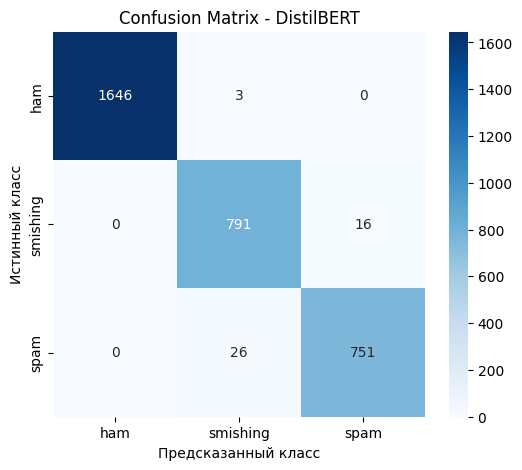

In [ ]:
cm = confusion_matrix(true_labels, preds)
labels = le.classes_

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix - DistilBERT")
plt.show()

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_encodings = tokenizer(
    list(train_df['TEXT']),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

test_encodings = tokenizer(
    list(test_df['TEXT']),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

In [ ]:
class SMSDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return item

In [ ]:
train_dataset = SMSDataset(train_encodings, y_train_labels)
test_dataset = SMSDataset(test_encodings, y_test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('roberta-base',num_labels=len(df['LABEL_ENC'].unique()))
model.to(device)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
num_epochs = 3
num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

In [ ]:
start_time_roberta = time.time()
train_losses = []
val_accuracies = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    preds_roberta = []
    true_labels_roberta = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)
            preds_roberta.extend(predictions.cpu().numpy())
            true_labels_roberta.extend(batch['labels'].cpu().numpy())

    acc = accuracy_score(true_labels_roberta, preds_roberta)
    val_accuracies.append(acc)
    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Accuracy={acc:.4f}")
end_time_roberta = time.time()
total_time = end_time_roberta - start_time_roberta

Epoch 1: Loss=0.2148, Val Accuracy=0.9731
Epoch 2: Loss=0.0822, Val Accuracy=0.9830
Epoch 3: Loss=0.0502, Val Accuracy=0.9833


In [ ]:
total_time

921.048846244812

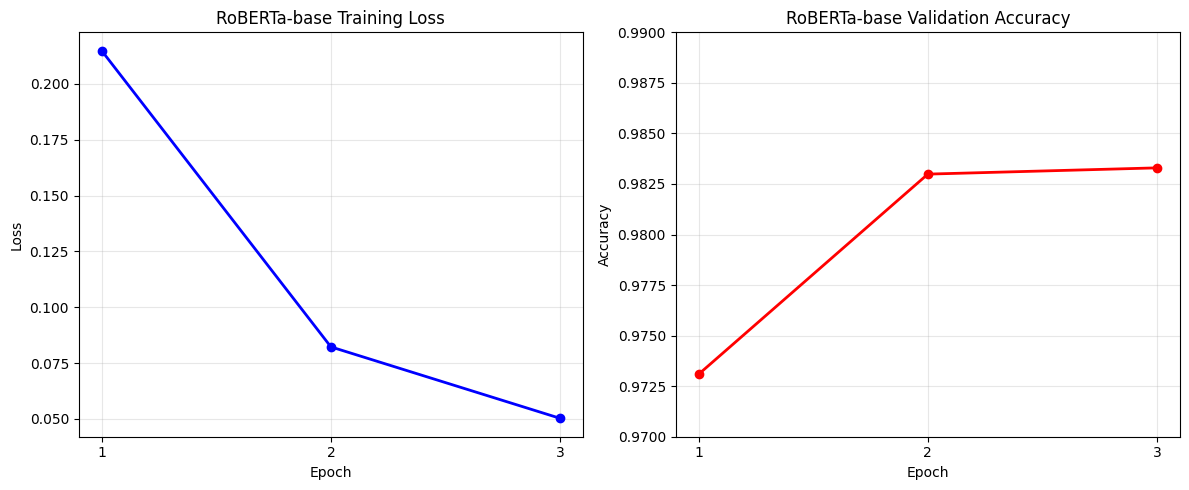

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.plot(range(1, len(train_losses)+1), train_losses, marker='o', color='blue', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('RoBERTa-base Training Loss')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, len(train_losses)+1))

ax2.plot(range(1, len(val_accuracies)+1), val_accuracies, marker='o', color='red', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('RoBERTa-base Validation Accuracy')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, len(val_accuracies)+1))
ax2.set_ylim(0.97, 0.99)

plt.tight_layout()
plt.show()

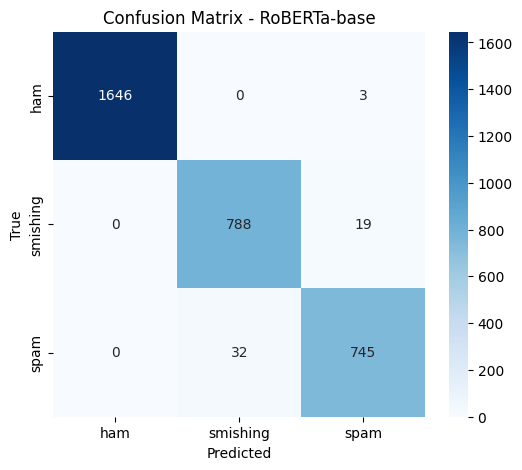

In [ ]:
cm = confusion_matrix(true_labels_roberta, preds_roberta)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - RoBERTa-base")
plt.show()

In [ ]:
def get_metrics(y_true, y_pred, model_name):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    accuracy = accuracy_score(y_true, y_pred)

    return pd.DataFrame({
        'Model': [model_name],
        'Accuracy': [accuracy],
        'Precision (weighted)': [precision],
        'Recall (weighted)': [recall],
        'F1-score (weighted)': [f1]
    })

metrics_lr = get_metrics(y_test, y_pred_lr, 'Logistic Regression')
metrics_nb = get_metrics(y_test, y_pred_nb, 'Naive Bayes')
metrics_xgb = get_metrics(y_test, y_pred_xgb, 'XGBoost')
metrics_bert = get_metrics(true_labels, preds, 'DistilBERT')
metrics_roberta = get_metrics(true_labels_roberta, preds_roberta, 'RoBERTa-base')

metrics_df = pd.concat(
    [metrics_lr, metrics_nb, metrics_xgb, metrics_bert, metrics_roberta],
    ignore_index=True
)

metrics_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
0,Logistic Regression,0.978039,0.978187,0.978039,0.978099
1,Naive Bayes,0.953913,0.953632,0.953913,0.953666
2,XGBoost,0.978967,0.978897,0.978967,0.978924
3,DistilBERT,0.986081,0.986159,0.986081,0.986094
4,RoBERTa-base,0.983297,0.983365,0.983297,0.983306


DistilBERT продемонстрировал наилучший результат на SMS датасете, эффективно различает все три класса, и показывает преимущества использования предобученных трансформеров для коротких текстов.